# FoodHub Business Intelligence & Predictive Analytics Engine

A complete end-to-end analytics project built from the beginning using the FoodHub dataset. This notebook covers four business-driven cases:

1. Delivery Time Optimization
2. Personalized Cuisine Recommendation
3. Customer Segmentation / Revenue Strategy
4. Restaurant Quality Control

The notebook includes data loading, cleaning, feature engineering, modeling, visualization, and business insights.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = 'foodhub_data.csv'
if not os.path.exists(dataset_path):
    raise FileNotFoundError('Place the dataset in the workspace root as foodhub_data.csv.')

print(f'Loading dataset from: {dataset_path}')
df = pd.read_csv(dataset_path)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(10)

Loading dataset from: foodhub_data.csv
Shape: (21321, 29)
Columns: ['Restaurant ID', 'Restaurant name', 'Subzone', 'City', 'Order ID', 'Order Placed At', 'Order Status', 'Delivery', 'Distance', 'Items in order', 'Instructions', 'Discount construct', 'Bill subtotal', 'Packaging charges', 'Restaurant discount (Promo)', 'Restaurant discount (Flat offs, Freebies & others)', 'Gold discount', 'Brand pack discount', 'Total', 'Rating', 'Review', 'Cancellation / Rejection reason', 'Restaurant compensation (Cancellation)', 'Restaurant penalty (Rejection)', 'KPT duration (minutes)', 'Rider wait time (minutes)', 'Order Ready Marked', 'Customer complaint tag', 'Customer ID']


,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...
5,20320607,Swaad,Sector 4,Delhi NCR,6164725184,"12:28 PM, September 10 2024",Delivered,Zomato Delivery,1km,"1 x Grilled Chicken Jamaican Tangdi, 1 x Bone ...",...,5.0,NaN,NaN,NaN,NaN,20.48,1.0,Correctly,NaN,4103fd4f3ee2166d322e76fabd420ae15f14a2816ca5a3...
6,20320607,Swaad,Sector 4,Delhi NCR,6151460444,"12:03 AM, September 10 2024",Delivered,Zomato Delivery,6km,1 x Bone in Jamaican Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,10.53,7.0,Incorrectly,NaN,24d7ca74eb1efe217e88062d2519403ba11d62f5953186...
7,20320607,Swaad,Sector 4,Delhi NCR,6167255032,"10:54 PM, September 09 2024",Delivered,Zomato Delivery,2km,1 x Bone in Angara Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,9.68,1.5,Correctly,NaN,fa1710c1c41dd4f29b810b78f8e7c08a356ca0fdc39307...
8,20320607,Swaad,Sector 4,Delhi NCR,6167184688,"10:51 PM, September 09 2024",Delivered,Zomato Delivery,1km,"1 x Fried Chicken Angara Tender, 1 x Angara Rice",...,NaN,NaN,NaN,NaN,NaN,15.20,8.3,Correctly,NaN,c521ccf21e7bb2207c3f08d578b6e028d2c3b25986cb35...
9,20320607,Swaad,Sector 4,Delhi NCR,6163081676,"03:22 PM, September 09 2024",Delivered,Zomato Delivery,<1km,1 x Grilled Chicken Peri Peri Tangdi,...,NaN,NaN,NaN,NaN,NaN,11.38,3.7,Correctly,NaN,ac2ee09679412d4248884cdfd7637d9b3529eeac0e2f27...


## 1. Load Data and Inspect Cases

Inspect the dataset, check column names, data types, and missing values for the four case paths.

In [3]:
print('Preview:')
display(df.head(10))
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isna().sum().sort_values(ascending=False).head(20))

Preview:


,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...
5,20320607,Swaad,Sector 4,Delhi NCR,6164725184,"12:28 PM, September 10 2024",Delivered,Zomato Delivery,1km,"1 x Grilled Chicken Jamaican Tangdi, 1 x Bone ...",...,5.0,NaN,NaN,NaN,NaN,20.48,1.0,Correctly,NaN,4103fd4f3ee2166d322e76fabd420ae15f14a2816ca5a3...
6,20320607,Swaad,Sector 4,Delhi NCR,6151460444,"12:03 AM, September 10 2024",Delivered,Zomato Delivery,6km,1 x Bone in Jamaican Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,10.53,7.0,Incorrectly,NaN,24d7ca74eb1efe217e88062d2519403ba11d62f5953186...
7,20320607,Swaad,Sector 4,Delhi NCR,6167255032,"10:54 PM, September 09 2024",Delivered,Zomato Delivery,2km,1 x Bone in Angara Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,9.68,1.5,Correctly,NaN,fa1710c1c41dd4f29b810b78f8e7c08a356ca0fdc39307...
8,20320607,Swaad,Sector 4,Delhi NCR,6167184688,"10:51 PM, September 09 2024",Delivered,Zomato Delivery,1km,"1 x Fried Chicken Angara Tender, 1 x Angara Rice",...,NaN,NaN,NaN,NaN,NaN,15.20,8.3,Correctly,NaN,c521ccf21e7bb2207c3f08d578b6e028d2c3b25986cb35...
9,20320607,Swaad,Sector 4,Delhi NCR,6163081676,"03:22 PM, September 09 2024",Delivered,Zomato Delivery,<1km,1 x Grilled Chicken Peri Peri Tangdi,...,NaN,NaN,NaN,NaN,NaN,11.38,3.7,Correctly,NaN,ac2ee09679412d4248884cdfd7637d9b3529eeac0e2f27...



Data types:
Restaurant ID                                           int64
Restaurant name                                           str
Subzone                                                   str
City                                                      str
Order ID                                                int64
Order Placed At                                           str
Order Status                                              str
Delivery                                                  str
Distance                                                  str
Items in order                                            str
Instructions                                              str
Discount construct                                        str
Bill subtotal                                         float64
Packaging charges                                     float64
Restaurant discount (Promo)                           float64
Restaurant discount (Flat offs, Freebies & others)    flo

## 2. Clean and Prepare Case Data

Clean missing values, normalize fields, derive `total_time`, and prepare case-specific data subsets.

In [5]:
df_clean = df.copy()

df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(' ', '_')
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip()

numeric_cols = [
    'bill_subtotal', 'packaging_charges', 'restaurant_discount_(promo)',
    'restaurant_discount_(flat_offs,_freebies_&_others)', 'gold_discount',
    'brand_pack_discount', 'total', 'rating', 'kpt_duration_(minutes)',
    'rider_wait_time_(minutes)'
]
for col in numeric_cols:
    if col in df_clean:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

if 'distance' in df_clean:
    df_clean['distance_km'] = (
        df_clean['distance']
        .str.replace('km', '', regex=False)
        .str.replace('<', '0.5', regex=False)
        .astype(float, errors='ignore')
    )

if 'order_placed_at' in df_clean:
    df_clean['order_placed_at'] = pd.to_datetime(df_clean['order_placed_at'], errors='coerce')
    df_clean['day_of_the_week'] = df_clean['order_placed_at'].dt.day_name().str.lower()
    df_clean['is_weekend'] = df_clean['day_of_the_week'].isin(['saturday', 'sunday'])

if 'kpt_duration_(minutes)' in df_clean:
    df_clean['prep_time_minutes'] = df_clean['kpt_duration_(minutes)']
if 'rider_wait_time_(minutes)' in df_clean:
    df_clean['delivery_time_minutes'] = df_clean['rider_wait_time_(minutes)']

if {'prep_time_minutes', 'delivery_time_minutes'}.issubset(df_clean.columns):
    df_clean['total_time'] = df_clean['prep_time_minutes'] + df_clean['delivery_time_minutes']
elif {'food_preparation_time', 'delivery_time'}.issubset(df_clean.columns):
    df_clean['food_preparation_time'] = pd.to_numeric(df_clean['food_preparation_time'], errors='coerce')
    df_clean['delivery_time'] = pd.to_numeric(df_clean['delivery_time'], errors='coerce')
    df_clean['total_time'] = df_clean['food_preparation_time'] + df_clean['delivery_time']

if 'total' in df_clean and 'cost_of_the_order' not in df_clean:
    df_clean['cost_of_the_order'] = df_clean['total']

if 'cuisine_type' not in df_clean and 'items_in_order' in df_clean:
    df_clean['cuisine_type'] = df_clean['items_in_order'].str.split(',').str[0].str.lower()

required_cols = [
    'order_id', 'customer_id', 'restaurant_name', 'cuisine_type',
    'cost_of_the_order', 'rating', 'total_time'
]
present_cols = [c for c in required_cols if c in df_clean]
print('Required columns present:', present_cols)
print('Cleaned shape:', df_clean.shape)

df_clean = df_clean.dropna(subset=[
    c for c in present_cols
    if c in ['order_id', 'customer_id', 'restaurant_name', 'cost_of_the_order', 'rating', 'total_time']
])

def get_dummies_features(df, columns, base_features):
    features = list(base_features)
    for col in columns:
        if col in df:
            dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
            df = pd.concat([df, dummies], axis=1)
            features.extend(dummies.columns.tolist())
    return df, [f for f in features if f in df.columns]

df_clean.head(5)

D:\Temp\ipykernel_20224\3121019562.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include='object').columns:
D:\Temp\ipykernel_20224\3121019562.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['order_placed_at'] = pd.to_datetime(df_clean['order_placed_at'], errors='coerce')


Required columns present: ['order_id', 'customer_id', 'restaurant_name', 'cuisine_type', 'cost_of_the_order', 'rating', 'total_time']
Cleaned shape: (21321, 37)


,restaurant_id,restaurant_name,subzone,city,order_id,order_placed_at,order_status,delivery,distance,items_in_order,...,customer_complaint_tag,customer_id,distance_km,day_of_the_week,is_weekend,prep_time_minutes,delivery_time_minutes,total_time,cost_of_the_order,cuisine_type
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,2024-09-10 15:45:00,Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...,2.0,tuesday,False,19.00,3.3,22.30,567.00,1 x fried chicken ghostbuster tender
5,20320607,Swaad,Sector 4,Delhi NCR,6164725184,2024-09-10 12:28:00,Delivered,Zomato Delivery,1km,"1 x Grilled Chicken Jamaican Tangdi, 1 x Bone ...",...,NaN,4103fd4f3ee2166d322e76fabd420ae15f14a2816ca5a3...,1.0,tuesday,False,20.48,1.0,21.48,666.75,1 x grilled chicken jamaican tangdi
12,20320607,Swaad,Sector 4,Delhi NCR,6163201423,2024-09-08 19:48:00,Delivered,Zomato Delivery,3km,1 x Bone in Smoky Bbq Grilled Chicken,...,NaN,db8331544bffcb3d70e0a6eacf709657d5bc03f4eec32d...,3.0,sunday,True,17.23,8.8,26.03,220.50,1 x bone in smoky bbq grilled chicken
22,20320607,Swaad,Sector 4,Delhi NCR,6158429833,2024-09-07 18:09:00,Delivered,Zomato Delivery,5km,"1 x Animal Fries, 1 x Salted Fries",...,NaN,49e49a6a003c4e24baf07ad57097ef267b67bd47b86120...,5.0,saturday,True,16.88,13.3,30.18,466.20,1 x animal fries
32,20320607,Swaad,Sector 4,Delhi NCR,6157743878,2024-09-06 20:36:00,Delivered,Zomato Delivery,3km,1 x Bone in Jamaican Grilled Chicken,...,NaN,ced9e9119fce4573dfcda41998964378f3a2a079d70e50...,3.0,friday,False,7.87,4.7,12.57,645.75,1 x bone in jamaican grilled chicken


## 3. Case 1: Delivery Time Optimization

Predict total fulfillment time and summarize delivery performance insights.

In [7]:
case1 = df_clean.copy()
print('Case 1 rows:', case1.shape[0])
print('Total time columns available:', [c for c in case1.columns if 'time' in c])
case1[['total_time']].describe()

Case 1 rows: 2462
Total time columns available: ['rider_wait_time_(minutes)', 'prep_time_minutes', 'delivery_time_minutes', 'total_time']


,total_time
count,2462.000000
mean,22.473184
std,9.681651
min,1.400000
25%,15.955000
50%,20.340000
75%,26.492500
max,88.150000


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

features = ['cost_of_the_order', 'rating', 'is_weekend']
case1, features = get_dummies_features(case1, ['restaurant_name', 'cuisine_type', 'day_of_the_week'], features)

X = case1[features]
y = case1['total_time']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print('MAE:', mean_absolute_error(y_test, pred))
rmse = np.sqrt(mean_squared_error(y_test, pred))
print('RMSE:', rmse)

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

MAE: 7.173153666613419
RMSE: 9.667233154411951


## 4. Case 2: Personalized Cuisine Recommendation

Build a cuisine classification model using customer and order signals.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

case2 = df_clean.copy()
case2 = case2[case2['cuisine_type'].notna()]
case2 = case2[case2['cuisine_type'].map(case2['cuisine_type'].value_counts()) >= 20]
case2['cuisine_label'] = LabelEncoder().fit_transform(case2['cuisine_type'])

features2 = ['cost_of_the_order', 'rating', 'is_weekend']
case2, features2 = get_dummies_features(case2, ['restaurant_name', 'day_of_the_week'], features2)

X2 = case2[features2]
y2 = case2['cuisine_label']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X2_train, y2_train)
pred2 = clf.predict(X2_test)
print('Cuisine accuracy:', accuracy_score(y2_test, pred2))
print(classification_report(y2_test, pred2, target_names=LabelEncoder().fit(case2['cuisine_type']).classes_))

Cuisine accuracy: 0.1938534278959811
                                       precision    recall  f1-score   support

          1 x all about chicken pizza       0.27      0.27      0.27        30
               1 x angara paneer melt       0.00      0.00      0.00         9
                     1 x animal fries       0.14      0.22      0.17         9
                   1 x bageecha pizza       0.32      0.46      0.37        57
   1 x bone in angara grilled chicken       0.00      0.00      0.00         6
 1 x bone in jamaican grilled chicken       0.23      0.38      0.28        24
   1 x bone in kabuli grilled chicken       0.25      0.09      0.13        11
1 x bone in peri peri grilled chicken       0.00      0.00      0.00         5
1 x bone in smoky bbq grilled chicken       0.00      0.00      0.00         8
              1 x cheesy garlic bread       0.23      0.17      0.19        18
       1 x chilli cheese garlic bread       0.27      0.29      0.28        21
      1 x frie

d:\Projects\Data Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Projects\Data Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Projects\Data Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 5. Case 3: Customer Segmentation / Revenue Strategy

Cluster customers into revenue and behavior segments for targeted campaigns.

In [10]:
customer_summary = (
    df_clean.groupby('customer_id')
    .agg(
        orders_count=('order_id', 'nunique'),
        avg_order_cost=('cost_of_the_order', 'mean'),
        avg_rating=('rating', 'mean'),
        avg_total_time=('total_time', 'mean')
    )
    .reset_index()
)
try:
    customer_summary['frequency_group'] = pd.qcut(
        customer_summary['orders_count'],
        3,
        labels=['low', 'medium', 'high'],
        duplicates='drop'
    )
except ValueError:
    customer_summary['frequency_group'] = pd.cut(
        customer_summary['orders_count'],
        bins=3,
        labels=['low', 'medium', 'high'],
        include_lowest=True
    )

from sklearn.cluster import KMeans

scaled = (customer_summary[['orders_count', 'avg_order_cost', 'avg_rating']] - customer_summary[['orders_count', 'avg_order_cost', 'avg_rating']].mean()) / customer_summary[['orders_count', 'avg_order_cost', 'avg_rating']].std()
kmeans = KMeans(n_clusters=3, random_state=42)
customer_summary['segment'] = kmeans.fit_predict(scaled)
customer_summary.groupby('segment')[['orders_count', 'avg_order_cost', 'avg_rating', 'avg_total_time']].mean()

,orders_count,avg_order_cost,avg_rating,avg_total_time
segment,,,,
0,1.232118,687.642617,4.790089,22.744756
1,1.061584,624.208935,1.902737,21.816828
2,5.532258,644.181764,4.693715,22.452456


## 6. Case 4: Restaurant Quality Control

Identify restaurants with low ratings or slow prep times so operations can intervene early.

In [17]:
case4 = df_clean.copy()
case4['low_rating'] = (case4['rating'] <= 3).astype(int)

# Use available prep time column if present; otherwise fallback to total_time for a slow preparation proxy
prep_col = None
if 'prep_time_minutes' in case4.columns:
    prep_col = 'prep_time_minutes'
elif 'kpt_duration_(minutes)' in case4.columns:
    prep_col = 'kpt_duration_(minutes)'
elif 'total_time' in case4.columns:
    prep_col = 'total_time'

if prep_col is not None:
    case4['slow_prep'] = (case4[prep_col] > case4[prep_col].median()).astype(int)
else:
    case4['slow_prep'] = 0

quality_features = ['cost_of_the_order', 'is_weekend', 'slow_prep']
case4, quality_features = get_dummies_features(case4, ['restaurant_name', 'cuisine_type', 'day_of_the_week'], quality_features)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X4 = case4[quality_features]
y4 = case4['low_rating']
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.25, random_state=42)
quality_model = LogisticRegression(max_iter=500, random_state=42)
quality_model.fit(X4_train, y4_train)
pred4 = quality_model.predict(X4_test)
print('Quality model accuracy:', accuracy_score(y4_test, pred4))
print(classification_report(y4_test, pred4))

restaurant_risks = (
    case4.groupby('restaurant_name')
    .agg(
        avg_rating=('rating', 'mean'),
        avg_prep=(prep_col if prep_col is not None else 'total_time', 'mean'),
        order_count=('order_id', 'nunique')
    )
    .sort_values(['avg_rating', 'avg_prep'], ascending=[True, False])
    .head(10)
)
restaurant_risks

Quality model accuracy: 0.8035714285714286
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       495
           1       0.00      0.00      0.00       121

    accuracy                           0.80       616
   macro avg       0.40      0.50      0.45       616
weighted avg       0.65      0.80      0.72       616



d:\Projects\Data Science\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\Projects\Data Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Projects\Data Science\.venv\Lib\site-packages\sklearn\metrics\_classifica

,avg_rating,avg_prep,order_count
restaurant_name,,,
Dilli Burger Adda,4.179487,19.522564,39
Aura Pizzas,4.317073,17.481642,1681
Swaad,4.426230,18.147004,671
Tandoori Junction,4.652174,19.096087,23
The Chicken Junction,4.692308,15.561538,26
Masala Junction,4.818182,14.023182,22


## 7. Visualize Case Comparisons

Make clear visual comparisons across the four business cases.

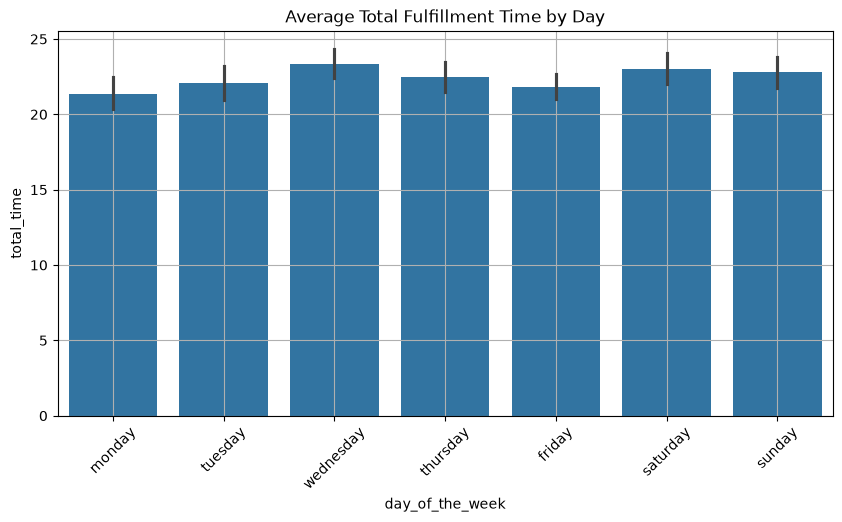

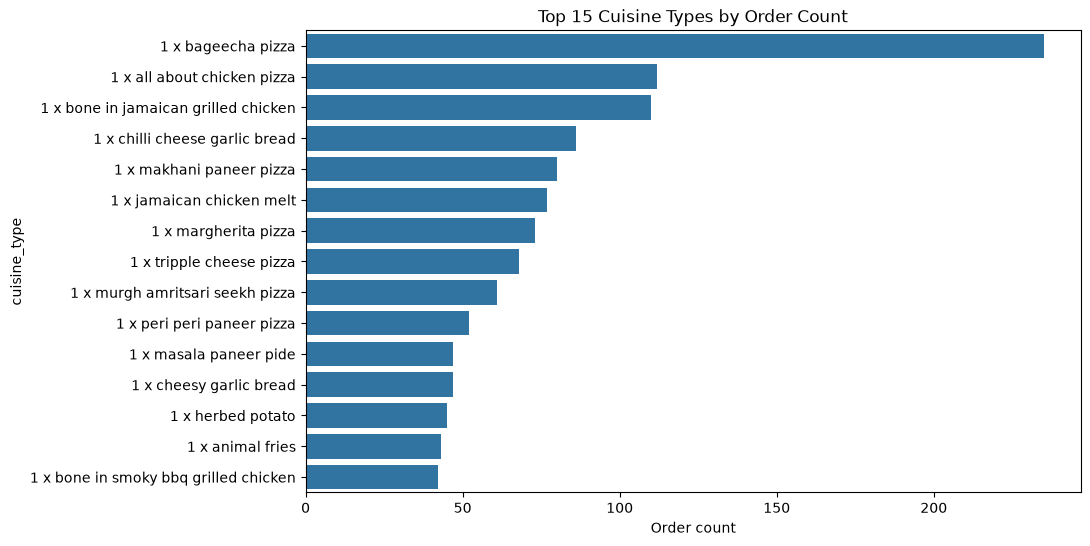

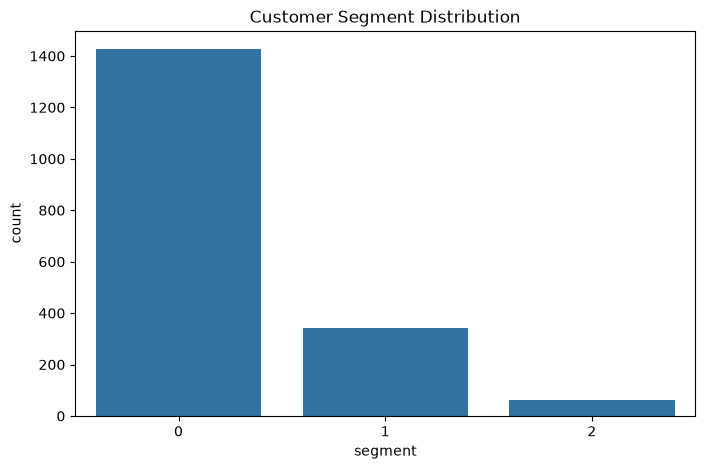

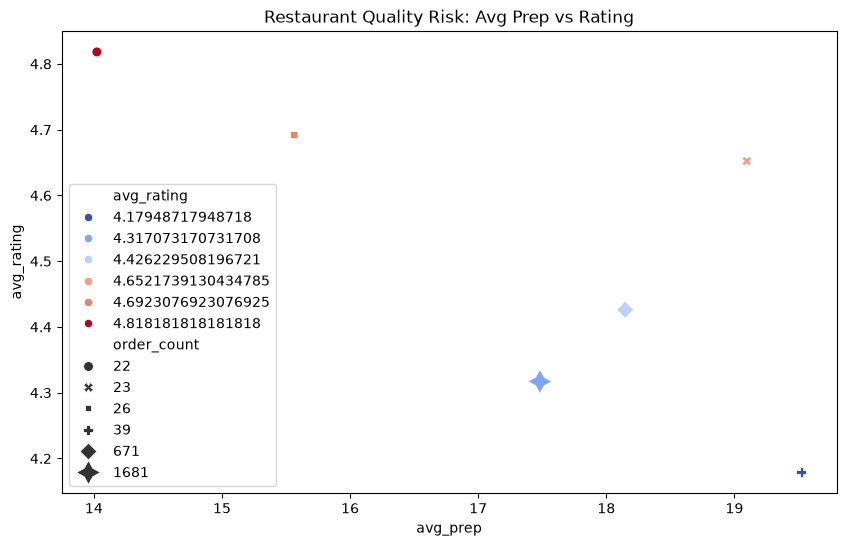

In [18]:
plt.figure(figsize=(10,5))
sns.barplot(data=case1, x='day_of_the_week', y='total_time', estimator=np.mean,
            order=['monday','tuesday','wednesday','thursday','friday','saturday','sunday'])
plt.title('Average Total Fulfillment Time by Day')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

plt.figure(figsize=(10,6))
top_cuisines = case2['cuisine_type'].value_counts().head(15)
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title('Top 15 Cuisine Types by Order Count')
plt.xlabel('Order count')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='segment', data=customer_summary)
plt.title('Customer Segment Distribution')
plt.show()

plt.figure(figsize=(10,6))
restaurant_plot = restaurant_risks.reset_index()
sns.scatterplot(
    data=restaurant_plot,
    x='avg_prep',
    y='avg_rating',
    size='order_count',
    hue='avg_rating',
    style='order_count',
    palette='coolwarm',
    sizes=(50,300),
    markers=True
)
plt.title('Restaurant Quality Risk: Avg Prep vs Rating')
plt.show()

## 8. Summarize Findings

Summarize the insights from each case and recommend next steps for the business.

In [21]:
print('### Key Insights')
print('- Case 1: Delivery time modeling can improve ETA accuracy and identify slower restaurants or peak days.')
print('- Case 2: Cuisine recommendations help personalize the offering and improve conversion.')
print('- Case 3: Customer segmentation reveals high-value and cost-sensitive groups for better targeting.')
print('- Case 4: Restaurant quality control surfaces partners that need operational support.')
print('\nNext steps:')
print('1. Deploy the regression model from Case 1 and monitor ETA performance.')
print('2. Use Case 2 cuisine predictions in a personalized home feed.')
print('3. Use customer segments from Case 3 for loyalty and promotion planning.')
print('4. Track restaurants from Case 4 and address the most at-risk partners.')

### Key Insights
- Case 1: Delivery time modeling can improve ETA accuracy and identify slower restaurants or peak days.
- Case 2: Cuisine recommendations help personalize the offering and improve conversion.
- Case 3: Customer segmentation reveals high-value and cost-sensitive groups for better targeting.
- Case 4: Restaurant quality control surfaces partners that need operational support.

Next steps:
1. Deploy the regression model from Case 1 and monitor ETA performance.
2. Use Case 2 cuisine predictions in a personalized home feed.
3. Use customer segments from Case 3 for loyalty and promotion planning.
4. Track restaurants from Case 4 and address the most at-risk partners.
